# Baseline 4 (Train from Scratch + Attention)

Cell 1: Cài đặt thư viện (Code)

In [ ]:
# Cài đặt phiên bản torch và torchtext tương thích
!pip install torch==2.3.1 torchvision==0.18.1 torchtext==0.18.0

In [ ]:
import os
from google.colab import drive
import torchtext
torchtext.disable_torchtext_deprecation_warning()
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import random
import json
import numpy as np
import spacy
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchtext.vocab import build_vocab_from_iterator
from tqdm.auto import tqdm

print("Đang kết nối với Google Drive...")
drive.mount('/content/drive')

def set_seed(seed=59):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Đang sử dụng thiết bị: {device}")

Đang kết nối với Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Đang sử dụng thiết bị: cuda


In [ ]:
%%bash
# Tạo thư mục chứa dữ liệu
mkdir -p /content/VQA_v2/Images
mkdir -p /content/VQA_v2/Text

# 1. Tải và giải nén MS COCO Val 2014 Images
echo "Đang tải MS COCO Val2014 Images..."
# Tải file (nếu chưa có)
wget -nc -q http://images.cocodataset.org/zips/val2014.zip
echo "Đang giải nén ảnh (Tự động ghi đè nếu đã tồn tại)..."
# Thêm -o để tự động overwrite không cần hỏi
unzip -q -o val2014.zip -d /content/VQA_v2/Images/
rm -f val2014.zip

# 2. Tải và giải nén VQA v2 Questions (Val)
echo "Đang tải VQA v2 Val Questions..."
wget -nc -q https://s3.amazonaws.com/cvmlp/vqa/mscoco/vqa/v2_Questions_Val_mscoco.zip
echo "Đang giải nén Questions..."
unzip -q -o v2_Questions_Val_mscoco.zip -d /content/VQA_v2/Text/
rm -f v2_Questions_Val_mscoco.zip

# 3. Tải và giải nén VQA v2 Annotations (Val)
echo "Đang tải VQA v2 Val Annotations..."
wget -nc -q https://s3.amazonaws.com/cvmlp/vqa/mscoco/vqa/v2_Annotations_Val_mscoco.zip
echo "Đang giải nén Annotations..."
unzip -q -o v2_Annotations_Val_mscoco.zip -d /content/VQA_v2/Text/
rm -f v2_Annotations_Val_mscoco.zip

echo "Hoàn tất tải và giải nén dữ liệu!"

Đang tải MS COCO Val2014 Images...
Đang giải nén ảnh (Tự động ghi đè nếu đã tồn tại)...
Đang tải VQA v2 Val Questions...
Đang giải nén Questions...
Đang tải VQA v2 Val Annotations...
Đang giải nén Annotations...
Hoàn tất tải và giải nén dữ liệu!


# Baseline 4: Train từ đầu (From Scratch) - CÓ Attention
**Kiến trúc:** Custom CNN (Bảo toàn không gian 7x7) + BiLSTM + Soft Attention + LSTM Decoder.

Mục tiêu của Baseline này là chứng minh rằng: Dù không dùng pre-trained model (khởi tạo tốn thời gian hội tụ hơn), nhưng nhờ có cơ chế Attention, mô hình vẫn có thể học được cách liên kết các vùng không gian trên ảnh với ngôn ngữ tự nhiên tốt hơn so với Baseline 3 (Không Attention).

In [ ]:
!python -m spacy download en_core_web_sm
nlp = spacy.load("en_core_web_sm")

def load_vqa_v2_data(img_dir, questions_path, annotations_path, split='train', limit=None):
    with open(questions_path, 'r') as f:
        q_data = json.load(f)['questions']
    with open(annotations_path, 'r') as f:
        a_data = json.load(f)['annotations']

    if limit:
        q_data = q_data[:limit]
        a_data = a_data[:limit]

    dataset = []
    for q, a in zip(q_data, a_data):
        img_id = q['image_id']
        img_name = f"COCO_val2014_{str(img_id).zfill(12)}.jpg"
        img_path = os.path.join(img_dir, img_name)

        if os.path.exists(img_path):
            dataset.append({'image_path': img_path, 'question': q['question'], 'answer': a['multiple_choice_answer']})
    return dataset

val_data = load_vqa_v2_data(
    '/content/VQA_v2/Images/val2014',
    '/content/VQA_v2/Text/v2_OpenEnded_mscoco_val2014_questions.json',
    '/content/VQA_v2/Text/v2_mscoco_val2014_annotations.json',
    split='val', limit=20000
)

random.shuffle(val_data)
train_size = int(0.8 * len(val_data))
train_data_split = val_data[:train_size]
val_data_split = val_data[train_size:]

def tokenize(text): return [tok.text.lower() for tok in nlp.tokenizer(text)]
def yield_tokens(data):
    for item in data:
        yield tokenize(item['question'])
        yield tokenize(item['answer'])

vocab = build_vocab_from_iterator(yield_tokens(train_data_split), specials=['<pad>', '<sos>', '<eos>', '<unk>'])
vocab.set_default_index(vocab['<unk>'])
PAD_IDX, SOS_IDX, EOS_IDX = vocab['<pad>'], vocab['<sos>'], vocab['<eos>']

class VQASeq2SeqDataset(Dataset):
    def __init__(self, data, vocab, transform=None, max_q_len=15, max_a_len=5):
        self.data = data
        self.vocab = vocab
        self.transform = transform
        self.max_q_len = max_q_len
        self.max_a_len = max_a_len

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = Image.open(item['image_path']).convert('RGB')
        if self.transform: image = self.transform(image)

        q_tokens = tokenize(item['question'])
        q_indices = [self.vocab[token] for token in q_tokens][:self.max_q_len]
        q_indices += [PAD_IDX] * max(0, self.max_q_len - len(q_indices))

        a_tokens = tokenize(item['answer'])
        a_indices = [SOS_IDX] + [self.vocab[token] for token in a_tokens][:self.max_a_len-2] + [EOS_IDX]
        a_indices += [PAD_IDX] * max(0, self.max_a_len - len(a_indices))

        return image, torch.tensor(q_indices), torch.tensor(a_indices)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = VQASeq2SeqDataset(train_data_split, vocab, transform)
val_dataset = VQASeq2SeqDataset(val_data_split, vocab, transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
print(f"Vocab size: {len(vocab)} | Train size: {len(train_dataset)} | Val size: {len(val_dataset)}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 119.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Vocab size: 5141 | Train size: 16000 | Val size: 4000


In [ ]:
# 1. Module Soft Attention
class SoftAttention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super(SoftAttention, self).__init__()
        self.encoder_att = nn.Linear(encoder_dim, attention_dim)
        self.decoder_att = nn.Linear(decoder_dim, attention_dim)
        self.full_att = nn.Linear(attention_dim, 1)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, encoder_out, decoder_hidden):
        att1 = self.encoder_att(encoder_out)
        att2 = self.decoder_att(decoder_hidden).unsqueeze(1)
        att = self.full_att(self.relu(att1 + att2)).squeeze(2)
        alpha = self.softmax(att)
        attention_weighted_encoding = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)
        return attention_weighted_encoding, alpha

# 2. Custom CNN (Giữ độ phân giải không gian 7x7)
class CustomCNNSpatial(nn.Module):
    def __init__(self, encoder_dim=512):
        super(CustomCNNSpatial, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2, 2), # 112
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2, 2), # 56
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2, 2), # 28
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2, 2), # 14
            nn.Conv2d(256, encoder_dim, kernel_size=3, padding=1), nn.BatchNorm2d(encoder_dim), nn.ReLU(), nn.MaxPool2d(2, 2) # 7x7
        )
        self.encoder_dim = encoder_dim

    def forward(self, x):
        x = self.features(x) # [Batch, 512, 7, 7]
        # Duỗi thành [Batch, 512, 49] sau đó đảo trục thành [Batch, 49, 512] để dùng cho Attention
        x = x.view(x.size(0), self.encoder_dim, -1).permute(0, 2, 1)
        return x

# 3. Mô hình tổng thể VQA
class VQA_CustomCNN_LSTM_Attention(nn.Module):
    def __init__(self, vocab_size, embed_size=256, hidden_size=512):
        super(VQA_CustomCNN_LSTM_Attention, self).__init__()

        self.cnn = CustomCNNSpatial(encoder_dim=512)
        self.encoder_dim = 512

        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.q_bilstm = nn.LSTM(embed_size, hidden_size // 2, bidirectional=True, batch_first=True)

        self.attention = SoftAttention(self.encoder_dim, hidden_size, attention_dim=256)

        # Decoder input = Context(512) + Question_Hidden(512) + Word_Embed(256) = 1280
        self.decoder_lstm = nn.LSTM(self.encoder_dim + hidden_size + embed_size, hidden_size, batch_first=True)
        self.fc_out = nn.Linear(hidden_size, vocab_size)

    def forward(self, images, questions, answers):
        batch_size = images.size(0)

        img_features = self.cnn(images) # [Batch, 49, 512]

        q_embed = self.embedding(questions)
        _, (q_hidden, _) = self.q_bilstm(q_embed)
        q_features = torch.cat((q_hidden[-2], q_hidden[-1]), dim=1) # [Batch, 512]

        ans_embed = self.embedding(answers)
        seq_len = ans_embed.size(1)

        logits = torch.zeros(batch_size, seq_len, self.fc_out.out_features).to(device)
        alphas = torch.zeros(batch_size, seq_len, 49).to(device)

        decoder_hidden = q_features.unsqueeze(0)
        decoder_cell = torch.zeros_like(decoder_hidden)

        for t in range(seq_len):
            context_vector, alpha = self.attention(img_features, decoder_hidden.squeeze(0))
            alphas[:, t, :] = alpha

            step_input = torch.cat((context_vector, q_features, ans_embed[:, t, :]), dim=1).unsqueeze(1)

            out, (decoder_hidden, decoder_cell) = self.decoder_lstm(step_input, (decoder_hidden, decoder_cell))
            logits[:, t, :] = self.fc_out(out.squeeze(1))

        return logits, alphas

In [ ]:
model = VQA_CustomCNN_LSTM_Attention(vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

def fit_attention_model(model, train_loader, val_loader, criterion, optimizer, epochs=20):
    train_losses, val_losses, val_accuracies = [], [], []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for images, questions, answers in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            images, questions, answers = images.to(device), questions.to(device), answers.to(device)
            ans_input, ans_target = answers[:, :-1], answers[:, 1:]

            optimizer.zero_grad()
            logits, _ = model(images, questions, ans_input)

            loss = criterion(logits.reshape(-1, logits.size(-1)), ans_target.reshape(-1))
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        train_losses.append(total_loss / len(train_loader))

        model.eval()
        val_loss, correct_matches, total_samples = 0, 0, 0
        with torch.no_grad():
            for images, questions, answers in val_loader:
                images, questions, answers = images.to(device), questions.to(device), answers.to(device)
                ans_input, ans_target = answers[:, :-1], answers[:, 1:]

                logits, _ = model(images, questions, ans_input)
                loss = criterion(logits.reshape(-1, logits.size(-1)), ans_target.reshape(-1))
                val_loss += loss.item()

                predictions = logits.argmax(dim=-1)
                for i in range(answers.size(0)):
                    pred_seq = [token.item() for token in predictions[i] if token.item() != EOS_IDX]
                    target_seq = [token.item() for token in ans_target[i] if token.item() != EOS_IDX]
                    if EOS_IDX in predictions[i]: pred_seq = pred_seq[:list(predictions[i]).index(EOS_IDX)]
                    if EOS_IDX in ans_target[i]: target_seq = target_seq[:list(ans_target[i]).index(EOS_IDX)]

                    if pred_seq == target_seq: correct_matches += 1
                    total_samples += 1

        val_losses.append(val_loss / len(val_loader))
        accuracy = (correct_matches / total_samples) * 100
        val_accuracies.append(accuracy)

        print(f"Epoch {epoch+1} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f} | Val Acc: {accuracy:.2f}%")

    return train_losses, val_losses, val_accuracies

train_losses, val_losses, val_accuracies = fit_attention_model(model, train_loader, val_loader, criterion, optimizer, epochs=20)

Epoch 1/20:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 1 | Train Loss: 2.9130 | Val Loss: 2.2855 | Val Acc: 25.30%


Epoch 2/20:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 2 | Train Loss: 2.1932 | Val Loss: 2.1518 | Val Acc: 26.47%


Epoch 3/20:   0%|          | 0/500 [00:00<?, ?it/s]

...

Epoch 18 | Train Loss: 0.9271 | Val Loss: 2.0763 | Val Acc: 30.60%


Epoch 19/20:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 19 | Train Loss: 0.8539 | Val Loss: 2.1166 | Val Acc: 30.80%


Epoch 20/20:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 20 | Train Loss: 0.7820 | Val Loss: 2.1506 | Val Acc: 30.95%


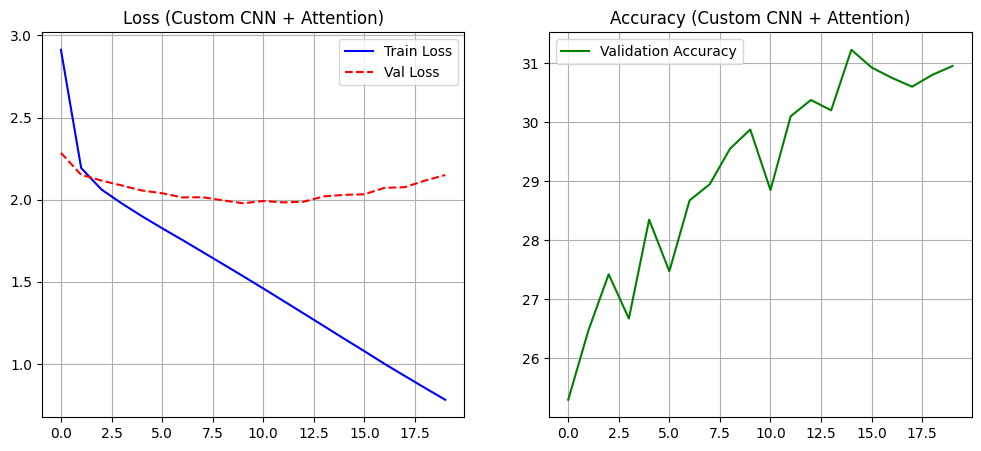

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='blue')
plt.plot(val_losses, label='Val Loss', color='red', linestyle='--')
plt.title('Loss (Custom CNN + Attention)')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label='Validation Accuracy', color='green')
plt.title('Accuracy (Custom CNN + Attention)')
plt.legend()
plt.grid()
plt.show()

save_dir = '/content/drive/MyDrive/VQA_Models'
os.makedirs(save_dir, exist_ok=True)
torch.save(model.state_dict(), os.path.join(save_dir, 'vqa_baseline4_attention_scratch.pth'))

[BASELINE 4 - CUSTOM CNN + ATTENTION]
Hỏi: are these skiers <unk> ??
Thực tế: no | AI dự đoán: no


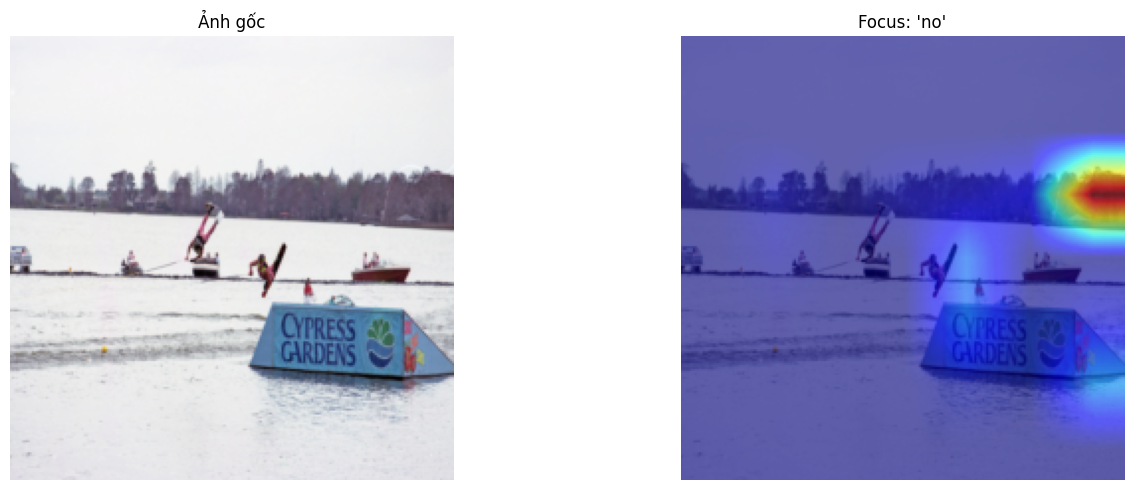

In [ ]:
import torch.nn.functional as F

def demo_attention_with_visualization(model, dataset, vocab, index=None, max_len=5, temperature=1.0):
    model.eval()
    if index is None: index = random.randint(0, len(dataset) - 1)

    img_tensor, q_tensor, ans_tensor = dataset[index]
    img_input = img_tensor.unsqueeze(0).to(device)
    q_input = q_tensor.unsqueeze(0).to(device)

    def get_word(idx):
        try: return vocab.lookup_token(idx)
        except: return '<unk>'

    with torch.no_grad():
        ans_in = torch.tensor([[SOS_IDX]]).to(device)
        pred_words, attention_maps = [], []

        for step in range(max_len):
            logits, alphas = model(img_input, q_input, ans_in)

            probs = torch.softmax(logits[:, -1, :] / temperature, dim=-1)
            next_word_idx = torch.multinomial(probs, num_samples=1).item()

            if next_word_idx == EOS_IDX: break

            pred_words.append(get_word(next_word_idx))
            attention_maps.append(alphas[:, -1, :].squeeze(0).cpu().numpy())

            ans_in = torch.cat([ans_in, torch.tensor([[next_word_idx]]).to(device)], dim=1)

    q_text = " ".join([get_word(idx) for idx in q_tensor.tolist() if get_word(idx) not in ['<pad>', '<sos>', '<eos>']])
    true_ans = " ".join([get_word(idx) for idx in ans_tensor.tolist() if get_word(idx) not in ['<pad>', '<sos>', '<eos>']])

    print(f"[BASELINE 4 - CUSTOM CNN + ATTENTION]")
    print(f"Hỏi: {q_text}?")
    print(f"Thực tế: {true_ans} | AI dự đoán: {' '.join(pred_words)}")

    img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
    img_np = np.clip((np.array([0.229, 0.224, 0.225]) * img_np + np.array([0.485, 0.456, 0.406])), 0, 1)

    fig = plt.figure(figsize=(15, 5))
    ax = fig.add_subplot(1, len(pred_words) + 1, 1)
    ax.imshow(img_np)
    ax.set_title("Ảnh gốc")
    ax.axis('off')

    for t in range(len(pred_words)):
        ax = fig.add_subplot(1, len(pred_words) + 1, t + 2)
        alpha_map = Image.fromarray(attention_maps[t].reshape(7, 7)).resize((224, 224), Image.BILINEAR)
        ax.imshow(img_np)
        ax.imshow(np.array(alpha_map), alpha=0.6, cmap='jet')
        ax.set_title(f"Focus: '{pred_words[t]}'")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

demo_attention_with_visualization(model, val_loader.dataset, vocab, temperature=1.0)